# Wildfires Modeling Notebook

Explore merged wildfires datasets, run EDA, train/evaluate the PyTorch model, and save an artifact.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, "..")

from models.wildfires import FEATURE_NAMES
from models.wildfires import save_model_bundle
from scripts.wildfires.train_model import (
    load_raw_dataset,
    prepare_training_dataframe,
    split_dataset,
    train_model,
)

In [3]:
raw_path = f"../data/wildfires/raw/wildfires_training_merged.csv"
raw_df = load_raw_dataset(Path(raw_path))
train_df = prepare_training_dataframe(raw_df)
print(f'Rows: {len(train_df)}')
print(raw_df['source'].value_counts())
train_df.head()

Rows: 760
source
uci_forestfires    517
uci_algerian       243
Name: count, dtype: int64


,temp_c,humidity_pct,wind_kph,ffmc,dmc,drought_code,isi,target
0,8.2,51.0,6.7,86.2,26.2,94.3,5.1,0.0
1,18.0,33.0,0.9,90.6,35.4,669.1,6.7,0.0
2,14.6,33.0,1.3,90.6,43.7,686.9,6.7,0.0
3,8.3,97.0,4.0,91.7,33.3,77.5,9.0,0.0
4,11.4,99.0,1.8,89.3,51.3,102.2,9.6,0.0


In [4]:
target_rate = train_df['target'].mean()
print(f'Positive class rate: {target_rate:.3f}')

train_df[FEATURE_NAMES].describe().T

Positive class rate: 0.536


,count,mean,std,min,25%,50%,75%,max
temp_c,760.0,23.129868,8.088921,2.2,17.60,22.35,30.00,42.0
humidity_pct,760.0,49.964474,17.881842,15.0,35.00,47.00,64.00,100.0
wind_kph,760.0,7.686974,5.778095,0.4,3.10,4.90,14.00,29.0
ffmc,760.0,86.551316,11.048296,18.7,85.40,90.70,92.30,96.2
dmc,760.0,80.116316,69.662335,0.7,16.50,73.40,126.50,291.3
drought_code,760.0,388.548289,310.939645,6.9,51.25,466.60,690.45,860.6
isi,760.0,7.653421,4.860433,0.0,4.10,7.50,9.80,56.1


Validation accuracy: 0.7697
Validation balanced accuracy: 0.7693
Validation AUROC: 0.8119


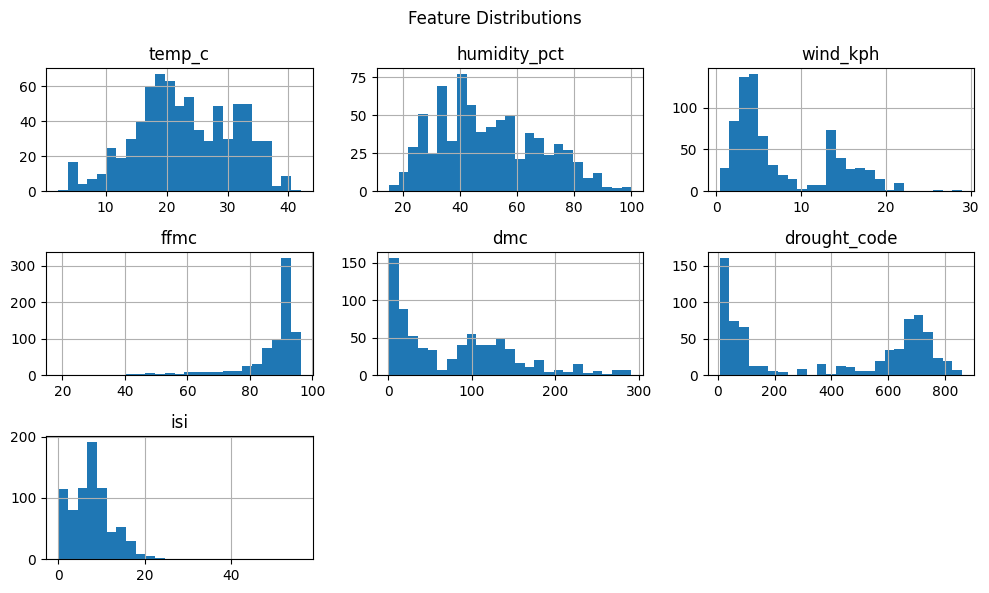

In [5]:
axes = train_df[FEATURE_NAMES].hist(figsize=(10, 6), bins=25)
plt.suptitle('Feature Distributions')
plt.tight_layout()

x_train, y_train, x_val, y_val = split_dataset(train_df, seed=42)
model, feature_mean, feature_std, val_accuracy, val_balanced_accuracy, val_auc = train_model(
    x_train=x_train,
    y_train=y_train,
    x_val=x_val,
    y_val=y_val,
    epochs=260,
    batch_size=64,
    learning_rate=8e-4,
    weight_decay=0.0,
    seed=41,
)
print(f'Validation accuracy: {val_accuracy:.4f}')
print(f'Validation balanced accuracy: {val_balanced_accuracy:.4f}')
print(f'Validation AUROC: {val_auc:.4f}')

In [6]:
model_path = "../models/wildfires.pt"
save_model_bundle(
    path=model_path,
    model=model,
    feature_mean=feature_mean,
    feature_std=feature_std,
    model_version='0.7.2',
    val_accuracy=val_accuracy,
    val_balanced_accuracy=val_balanced_accuracy,
    val_auc=val_auc,
    dataset_rows=int(len(train_df)),
)
print(f'Saved model artifact to: {model_path}')

Saved model artifact to: ../models/wildfires.pt
